In [10]:
import pandas as pd 
import seaborn as sns 
import numpy as np 
import matplotlib.pyplot as plt 
from matplotlib import dates 
from datetime import datetime

In [11]:
data = pd.read_csv('Walmart_Store_sales.csv') 
data 

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [12]:
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


In [14]:
# checking for missing values 
data.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [15]:
# Splitting Date and create new columns (Day, Month, and Year) 
data["Day"]= pd.DatetimeIndex(data['Date']).day 
data['Month'] = pd.DatetimeIndex(data['Date']).month 
data['Year'] = pd.DatetimeIndex(data['Date']).year 
data 

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Day,Month,Year
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,5,2,2010
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,12,2,2010
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,19,2,2010
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,26,2,2010
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,5,3,2010
...,...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,28,9,2012
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,5,10,2012
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,12,10,2012
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,19,10,2012


In [8]:
Q1: Which store has minimum and maximum sales?


Object `sales` not found.


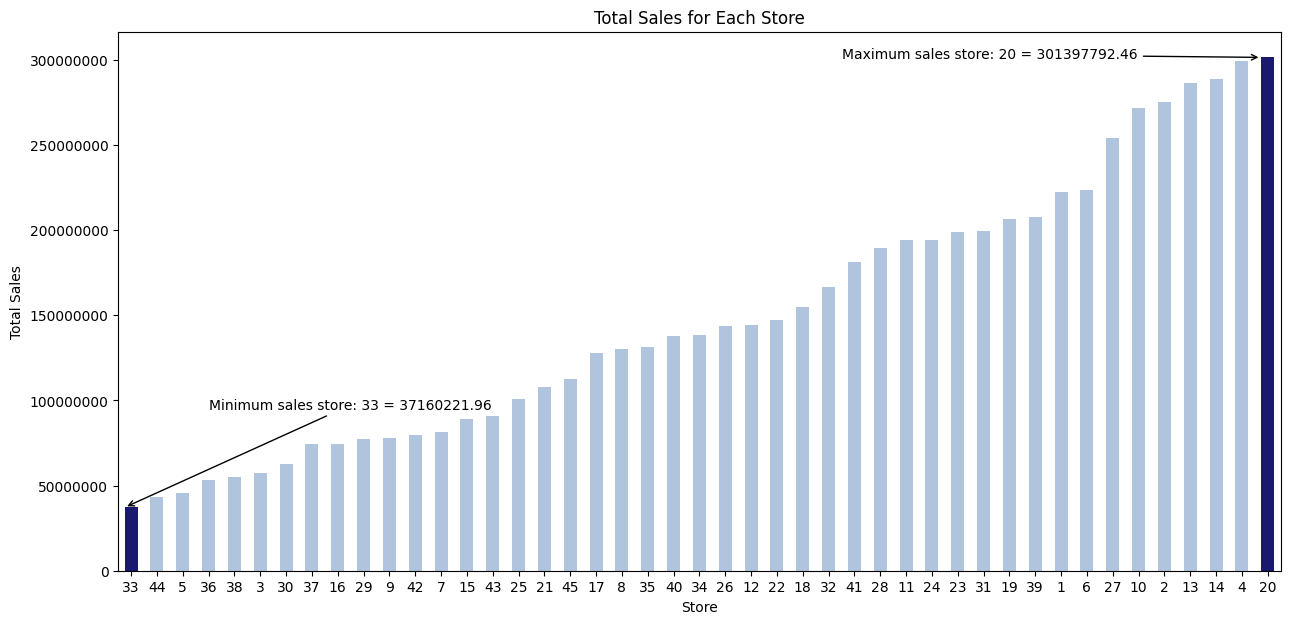

In [16]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(15,7))

# Total sales per store
total_sales_for_each_store = data.groupby('Store')['Weekly_Sales'].sum().sort_values()

total_sales_for_each_store_array = np.array(total_sales_for_each_store)

# Colors for bars
clrs = ['lightsteelblue' if ((x < max(total_sales_for_each_store_array)) and 
                             (x > min(total_sales_for_each_store_array))) 
        else 'midnightblue' for x in total_sales_for_each_store_array]

ax = total_sales_for_each_store.plot(kind='bar', color=clrs)

# Minimum sales store annotation
p_min = ax.patches[0]
ax.annotate(
    f"Minimum sales store: {total_sales_for_each_store.index[0]} = {p_min.get_height():.2f}",
    xy=(p_min.get_x(), p_min.get_height()),
    xytext=(0.2, 0.3),
    textcoords='axes fraction',
    arrowprops=dict(arrowstyle="->"),
    ha='center'
)

# Maximum sales store annotation
p_max = ax.patches[-1]
ax.annotate(
    f"Maximum sales store: {total_sales_for_each_store.index[-1]} = {p_max.get_height():.2f}",
    xy=(p_max.get_x(), p_max.get_height()),
    xytext=(0.75, 0.95),
    textcoords='axes fraction',
    arrowprops=dict(arrowstyle="->"),
    ha='center'
)

# Plot styling
plt.xticks(rotation=0)
plt.ticklabel_format(useOffset=False, style='plain', axis='y')
plt.title('Total Sales for Each Store')
plt.xlabel('Store')
plt.ylabel('Total Sales')

plt.show()

In [18]:
data_std = data.groupby('Store')['Weekly_Sales'].std().sort_values(ascending=False)

store = data_std.index[0]
value = data_std.values[0]

print(f"The store has maximum standard deviation is {store} with {value:.0f} $")

The store has maximum standard deviation is 14 with 317570 $


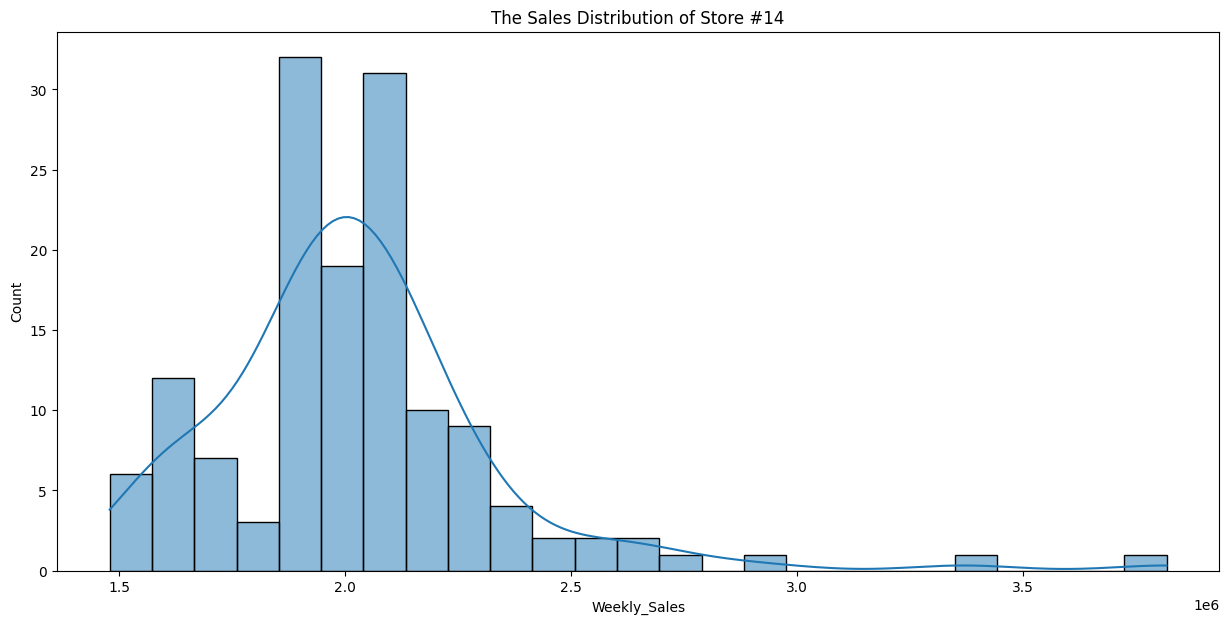

In [22]:
plt.figure(figsize=(15,7))

sns.histplot(data[data['Store'] == store_id]['Weekly_Sales'], kde=True)

plt.title(f"The Sales Distribution of Store #{store_id}")
plt.show()

In [26]:
# Coefficient of mean to standard deviation 
coef_mean_std = pd.DataFrame(data.groupby('Store')['Weekly_Sales'].std() / data.groupby('Store')['Weekly_Sales'].mean()) 
coef_mean_std = coef_mean_std.rename(columns={'Weekly_Sales':'Coefficient of mean to standard deviation'}) 
coef_mean_std 

,Coefficient of mean to standard deviation
Store,
1,0.100292
2,0.123424
3,0.115021
4,0.127083
5,0.118668
6,0.135823
7,0.197305
8,0.116953
9,0.126895


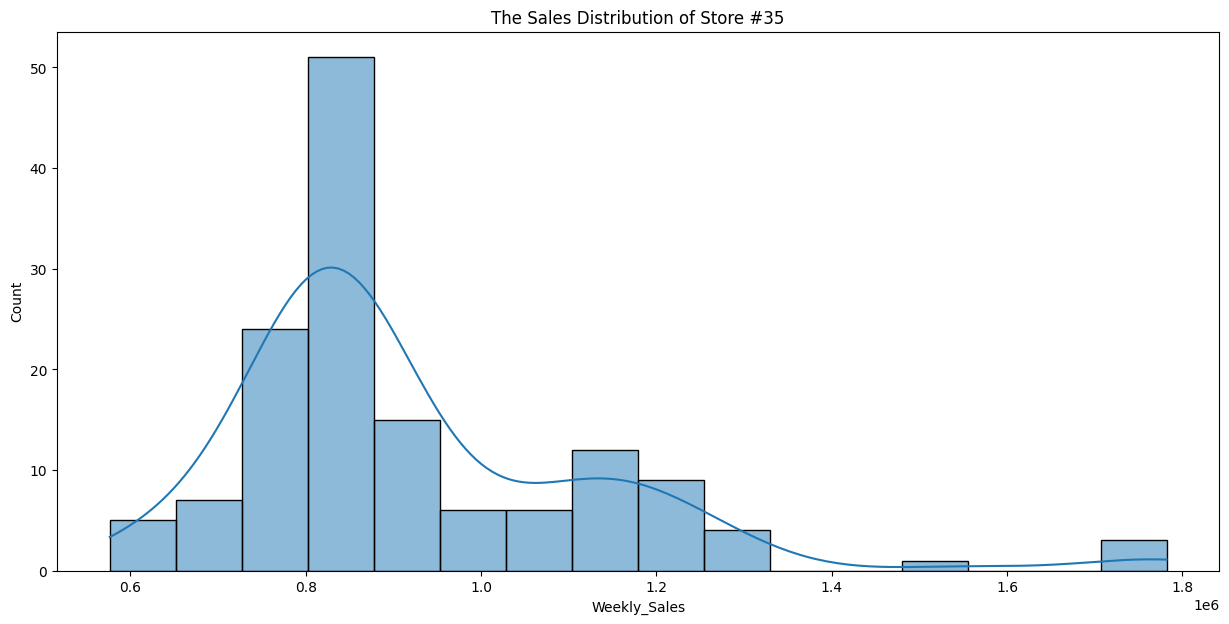

In [30]:
# Distribution of store has maximum coefficient of mean to standard deviation 
coef_mean_std_max = coef_mean_std.sort_values(
    by='Coefficient of mean to standard deviation'
)

store_id = coef_mean_std_max.tail(1).index[0]

plt.figure(figsize=(15,7))

sns.histplot(data[data['Store'] == store_id]['Weekly_Sales'], kde=True)

plt.title(f'The Sales Distribution of Store #{store_id}')
plt.show()

In [31]:
plt.figure(figsize=(15,7))


<Figure size 1500x700 with 0 Axes>

<Figure size 1500x700 with 0 Axes>

In [32]:
Q3 = data[(data['Date'] > '2012-07-01') & (data['Date'] < '2012-09-30')].groupby('Store')['Weekly_Sales'].sum()


In [33]:
Q2 = data[(data['Date'] > '2012-04-01') & (data['Date'] < '2012-06-30')].groupby('Store')['Weekly_Sales'].sum()


In [36]:
#  store/s has good quarterly growth rate in Q3’2012 - .sort_values(by='Weekly_Sales') 
print('Store have good quarterly growth rate in Q3’2012 is Store '+str(Q3.idxmax())+' With '+str(Q3.max())+' $');

Store have good quarterly growth rate in Q3’2012 is Store 4 With 27796792.46 $


In [41]:
total_sales = data.groupby('Date')['Weekly_Sales'].sum().reset_index()

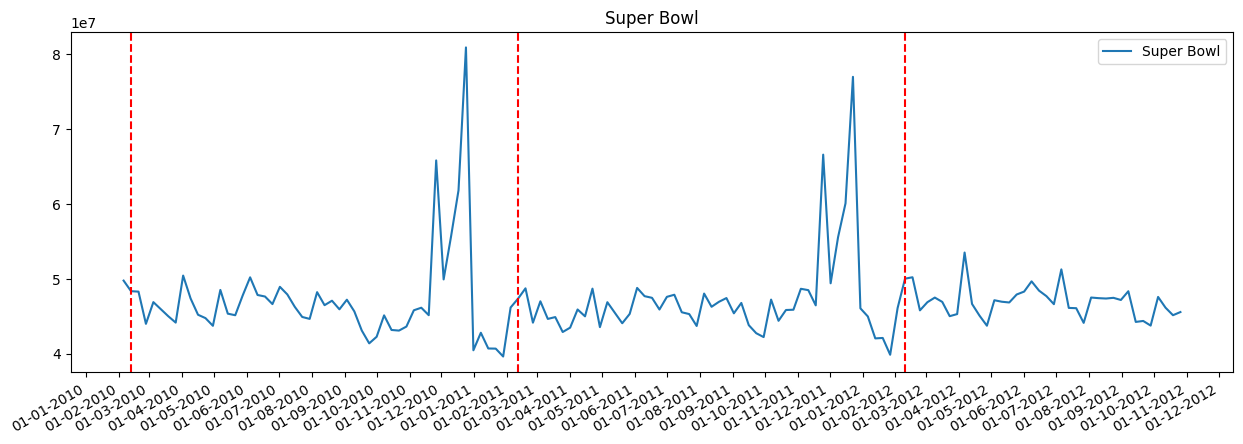

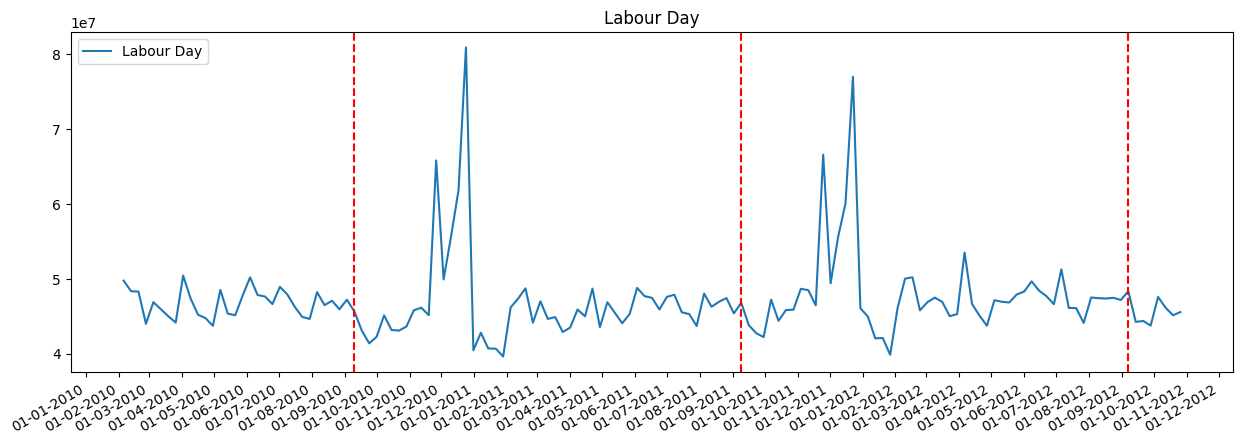

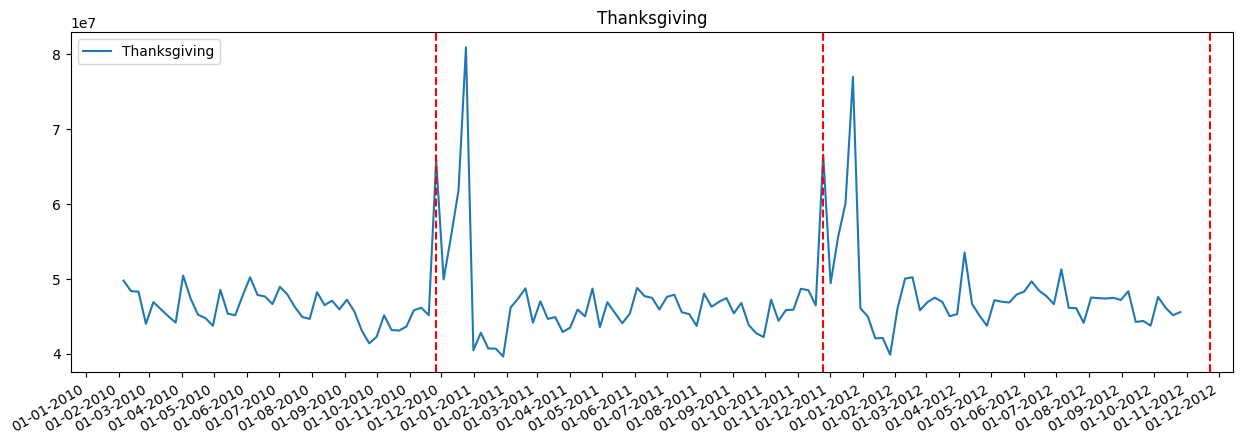

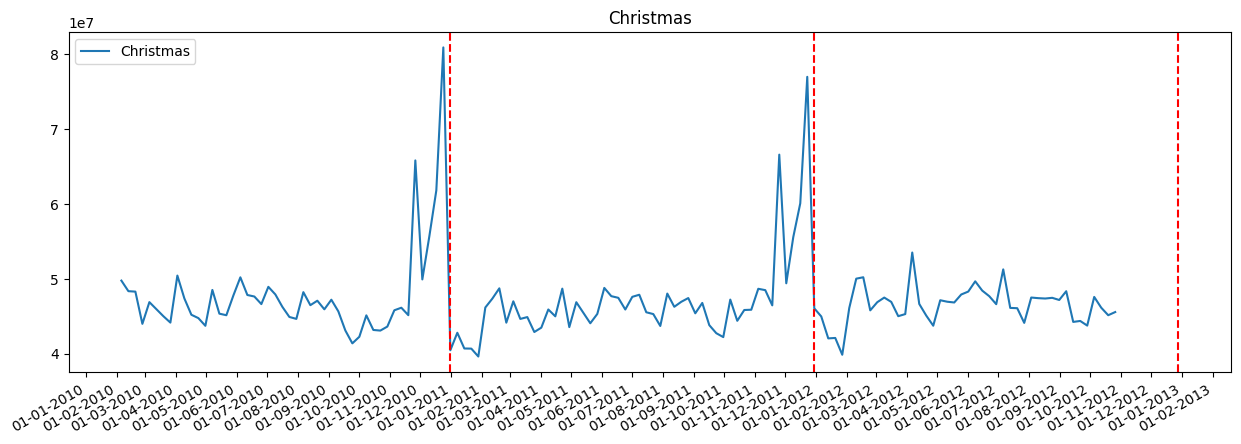

In [43]:
plot_line(total_sales, Super_Bowl, 'Super Bowl')
plot_line(total_sales, Labour_Day, 'Labour Day')
plot_line(total_sales, Thanksgiving, 'Thanksgiving')
plot_line(total_sales, Christmas, 'Christmas')

In [45]:
Super_Bowl = pd.to_datetime(['12-02-2010', '11-02-2011', '10-02-2012'], dayfirst=True)
Labour_Day = pd.to_datetime(['10-09-2010', '09-09-2011', '07-09-2012'], dayfirst=True)
Thanksgiving = pd.to_datetime(['26-11-2010', '25-11-2011', '23-11-2012'], dayfirst=True)
Christmas = pd.to_datetime(['31-12-2010', '30-12-2011', '28-12-2012'], dayfirst=True)

In [46]:
data.loc[data['Date'].isin(Super_Bowl)]

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Day,Month,Year
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,12,2,2010
53,1,2011-02-11,1649614.93,1,36.39,3.022,212.936705,7.742,11,2,2011
105,1,2012-02-10,1802477.43,1,48.02,3.409,220.265178,7.348,10,2,2012
144,2,2010-02-12,2137809.50,1,38.49,2.548,210.897994,8.324,12,2,2010
196,2,2011-02-11,2168041.61,1,33.19,3.022,212.592862,8.028,11,2,2011
...,...,...,...,...,...,...,...,...,...,...,...
6202,44,2011-02-11,307486.73,1,30.83,3.034,127.859129,7.224,11,2,2011
6254,44,2012-02-10,325377.97,1,33.73,3.116,130.384903,5.774,10,2,2012
6293,45,2010-02-12,656988.64,1,27.73,2.773,181.982317,8.992,12,2,2010
6345,45,2011-02-11,766456.00,1,30.30,3.239,183.701613,8.549,11,2,2011


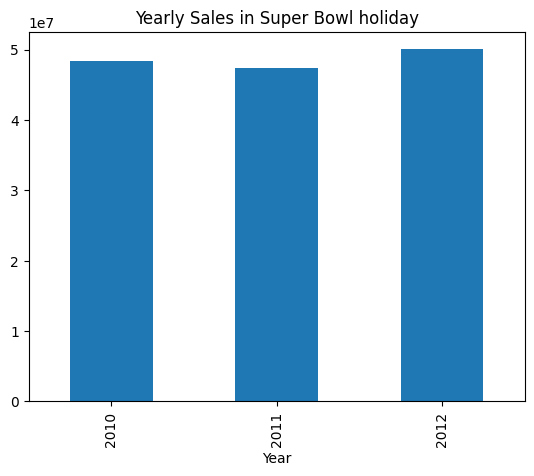

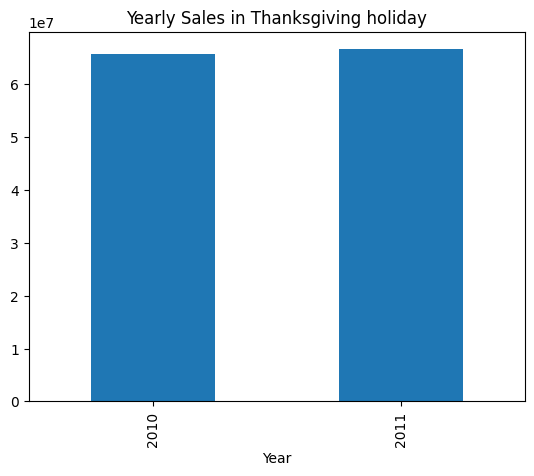

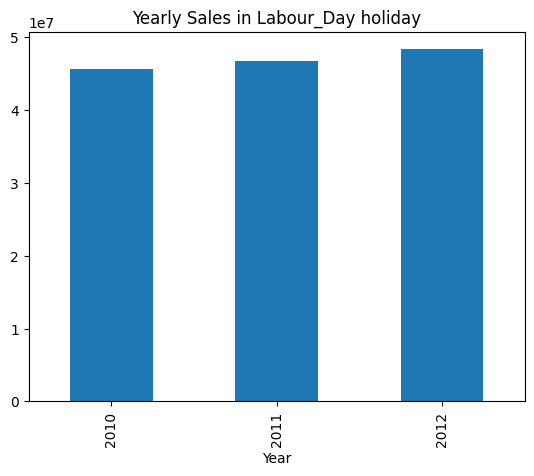

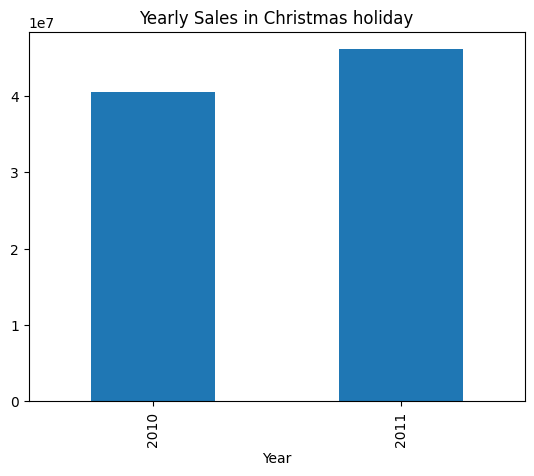

In [49]:
# Yearly Sales in holidays 
Super_Bowl_df = pd.DataFrame(data.loc[data.Date.isin(Super_Bowl)].groupby('Year')['Weekly_Sales'].sum()) 
Thanksgiving_df = pd.DataFrame(data.loc[data.Date.isin(Thanksgiving)].groupby('Year')['Weekly_Sales'].sum()) 
Labour_Day_df = pd.DataFrame(data.loc[data.Date.isin(Labour_Day)].groupby('Year')['Weekly_Sales'].sum()) 
Christmas_df = pd.DataFrame(data.loc[data.Date.isin(Christmas)].groupby('Year')['Weekly_Sales'].sum()) 
Super_Bowl_df.plot(kind='bar',legend=False,title='Yearly Sales in Super Bowl holiday')  
Thanksgiving_df.plot(kind='bar',legend=False,title='Yearly Sales in Thanksgiving holiday') 
Labour_Day_df.plot(kind='bar',legend=False,title='Yearly Sales in Labour_Day holiday') 
Christmas_df.plot(kind='bar',legend=False,title='Yearly Sales in Christmas holiday');

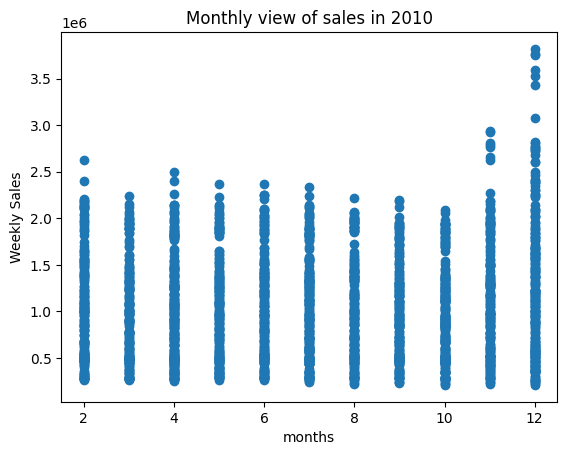

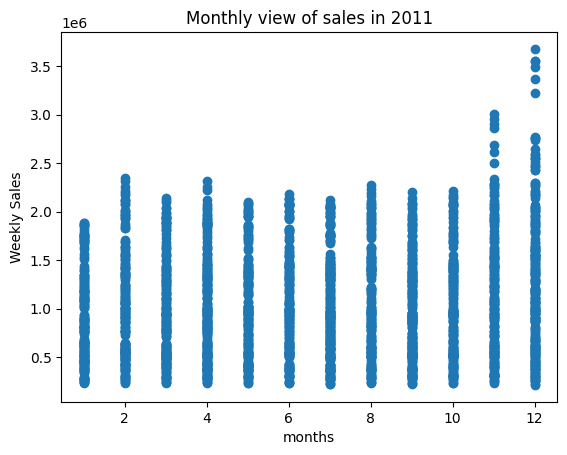

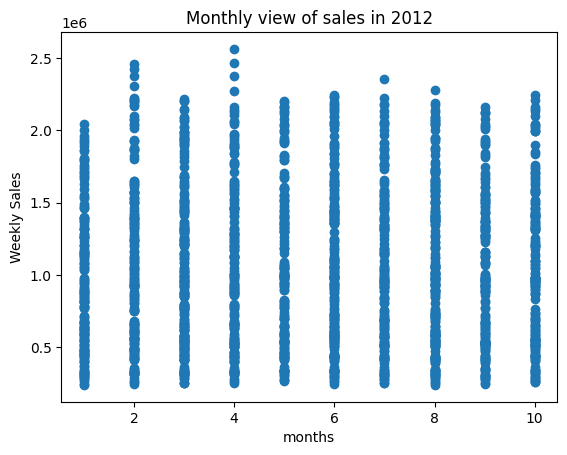

In [50]:
# Monthly view of sales for each years 
plt.scatter(data[data.Year==2010]["Month"],data[data.Year==2010]["Weekly_Sales"]) 
plt.xlabel("months") 
plt.ylabel("Weekly Sales") 
plt.title("Monthly view of sales in 2010") 
plt.show() 
plt.scatter(data[data.Year==2011]["Month"],data[data.Year==2011]["Weekly_Sales"]) 
plt.xlabel("months") 
plt.ylabel("Weekly Sales") 
plt.title("Monthly view of sales in 2011") 
plt.show() 
plt.scatter(data[data.Year==2012]["Month"],data[data.Year==2012]["Weekly_Sales"]) 
plt.xlabel("months") 
plt.ylabel("Weekly Sales") 
plt.title("Monthly view of sales in 2012") 
plt.show() 

Text(0.5, 1.0, 'Monthly view of sales')

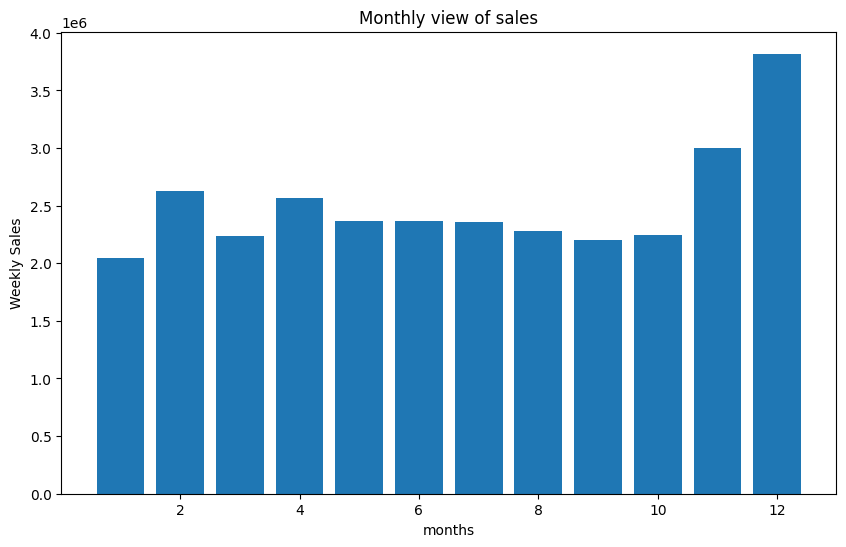

In [51]:
# Monthly view of sales for all years 
plt.figure(figsize=(10,6)) 
plt.bar(data["Month"],data["Weekly_Sales"]) 
plt.xlabel("months") 
plt.ylabel("Weekly Sales") 
plt.title("Monthly view of sales")

<Figure size 1000x600 with 0 Axes>

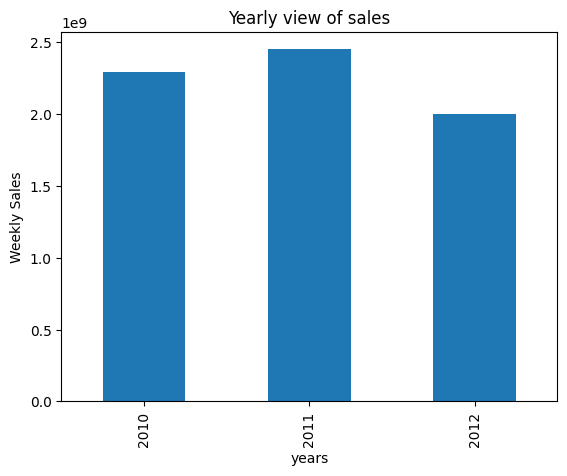

In [52]:
# Yearly view of sales 
plt.figure(figsize=(10,6)) 
data.groupby("Year")[["Weekly_Sales"]].sum().plot(kind='bar',legend=False)
plt.xlabel("years") 
plt.ylabel("Weekly Sales") 
plt.title("Yearly view of sales"); 

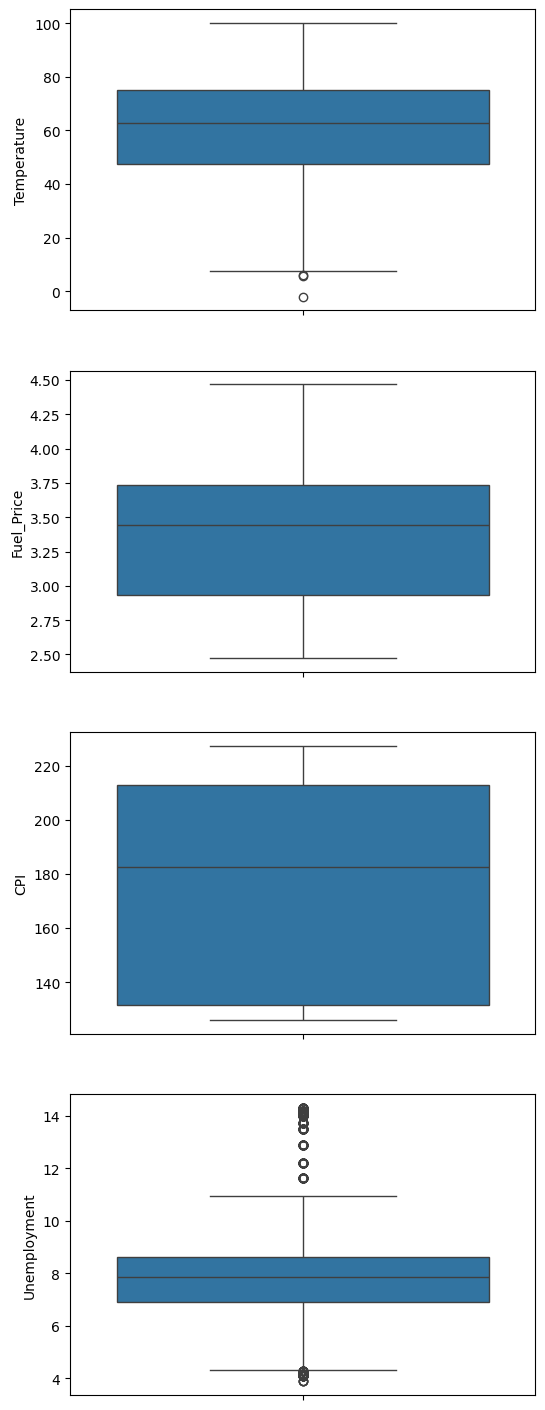

In [54]:
# find outliers  
fig, axs = plt.subplots(4,figsize=(6,18))
X = data[['Temperature','Fuel_Price','CPI','Unemployment']] 
for i,column in enumerate(X):
    sns.boxplot(data[column], ax=axs[i]);

In [55]:
# drop the outliers      
data_new = data[(data['Unemployment']<10) & (data['Unemployment']>4.5) & (data['Temperature']>10)] 
data_new 

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Day,Month,Year
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,5,2,2010
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,12,2,2010
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,19,2,2010
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,26,2,2010
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,5,3,2010
...,...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,28,9,2012
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,5,10,2012
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,12,10,2012
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,19,10,2012


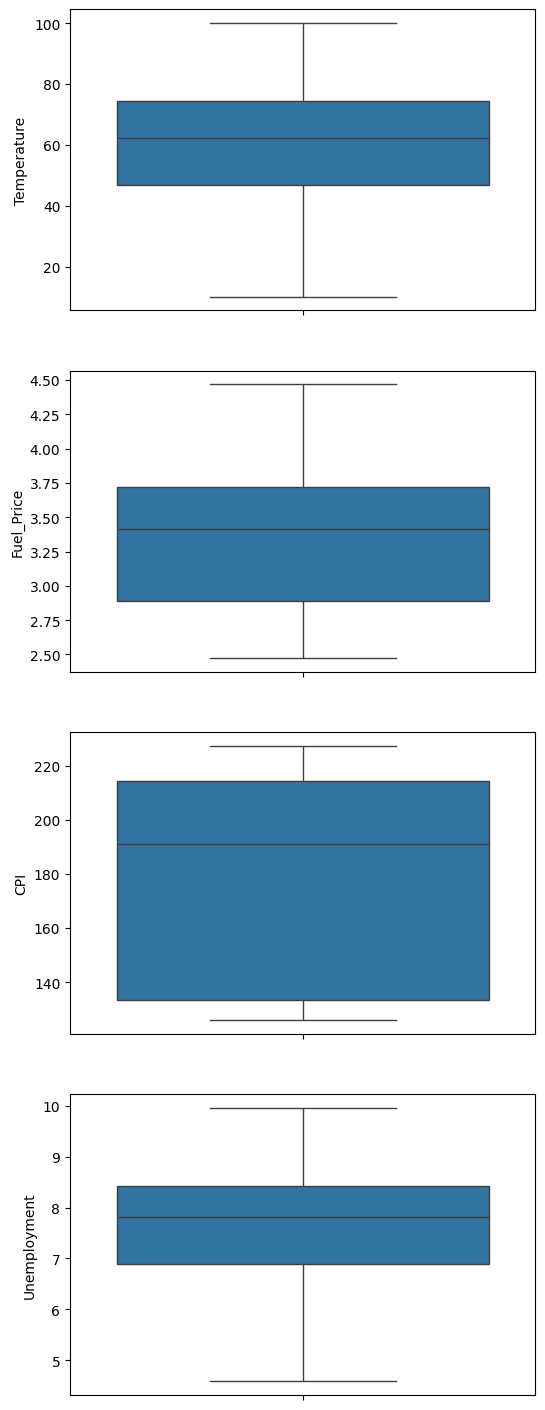

In [57]:
# check outliers  
fig, axs = plt.subplots(4,figsize=(6,18))
X = data_new[['Temperature','Fuel_Price','CPI','Unemployment']] 
for i,column in enumerate(X):
    sns.boxplot(data_new[column], ax=axs[i]);

In [58]:
#Build Model

In [59]:
# Import sklearn  
from sklearn.ensemble import RandomForestRegressor 
from sklearn.model_selection import train_test_split 
from sklearn import metrics 
from sklearn.linear_model import LinearRegression 

In [60]:
# Select features and target  
X = data_new[['Store','Fuel_Price','CPI','Unemployment','Day','Month','Year']] 
y = data_new['Weekly_Sales'] 
# Split data to train and test (0.80:0.20) 
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2);

Linear Regression:

Accuracy: 13.878375227002449
Mean Absolute Error: 442415.20416085096
Mean Squared Error: 285382988268.74426
Root Mean Squared Error: 534212.4935535898


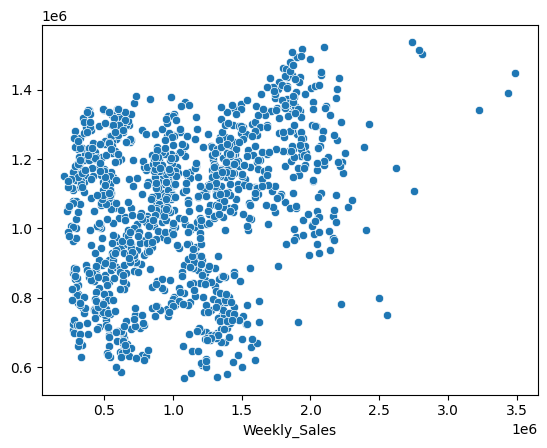

In [62]:
# Linear Regression model 
print('Linear Regression:') 
print() 
reg = LinearRegression() 
reg.fit(X_train, y_train) 
y_pred = reg.predict(X_test) 
print('Accuracy:',reg.score(X_train, y_train)*100) 
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred)) 
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred)) 
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred))) 
sns.scatterplot(x=y_test, y=y_pred); 